# Основное обучение

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

# Новые импорты для эксперимента
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import lightgbm as lgb

warnings.filterwarnings('ignore') # Отключаем лишние предупреждения
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Загрузка очищенного файла
df = pd.read_csv('../data/processed/cleaned_dataset.csv')
print(f"Общий размер данных: {df.shape}")

# Отсекаем последние 20% по времени для финальной проверки (Holdout Test)
split_index = int(len(df) * 0.8)
df_train = df.iloc[:split_index].copy()
df_test = df.iloc[split_index:].copy()

# Отделяем таргет и удаляем признаки, вызывающие утечку
cols_to_drop = ['isfraud', 'UserID', 'EventTime'] 

X_train = df_train.drop(columns=[col for col in cols_to_drop if col in df_train.columns])
y_train = df_train['isfraud']

X_test = df_test.drop(columns=[col for col in cols_to_drop if col in df_test.columns])
y_test = df_test['isfraud']

# Строгое приведение категориальных признаков к строкам
cat_features = ['hour', 'day_of_week']
for col in cat_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)

print(f"Train (пойдет в кросс-валидацию): {X_train.shape[0]} строк")
print(f"Test (финальная слепая проверка): {X_test.shape[0]} строк")

Общий размер данных: (3443864, 8)
Train (пойдет в кросс-валидацию): 2755091 строк
Test (финальная слепая проверка): 688773 строк


In [3]:
# 1. Инициализируем базовую модель
base_model = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0,
    task_type='GPU',
    devices='0'
)

# 2. Сетка гиперпараметров для перебора
param_grid = {
    'depth': [6, 8],
    'learning_rate': [0.03, 0.1],
    'iterations': [200, 500]
}

# 3. Временная кросс-валидация (3 исторических блока)
tscv = TimeSeriesSplit(n_splits=3)

# 4. Сборка GridSearch
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='average_precision', 
    verbose=2 # Выводит прогресс
)

# 5. Запуск
print("Начинаем подбор гиперпараметров")
grid_search.fit(X_train, y_train, cat_features=cat_features)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший PR-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

Начинаем подбор гиперпараметров
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ........depth=6, iterations=200, learning_rate=0.03; total time=   8.7s
[CV] END ........depth=6, iterations=200, learning_rate=0.03; total time=  14.7s
[CV] END ........depth=6, iterations=200, learning_rate=0.03; total time=  23.1s
[CV] END .........depth=6, iterations=200, learning_rate=0.1; total time=   7.4s
[CV] END .........depth=6, iterations=200, learning_rate=0.1; total time=  13.8s
[CV] END .........depth=6, iterations=200, learning_rate=0.1; total time=  21.6s
[CV] END ........depth=6, iterations=500, learning_rate=0.03; total time=  15.9s
[CV] END ........depth=6, iterations=500, learning_rate=0.03; total time=  30.4s
[CV] END ........depth=6, iterations=500, learning_rate=0.03; total time=  49.6s
[CV] END .........depth=6, iterations=500, learning_rate=0.1; total time=  16.1s
[CV] END .........depth=6, iterations=500, learning_rate=0.1; total time=  30.8s
[CV] END ........

In [4]:
# Достаем лучшую модель из GridSearch
best_model = grid_search.best_estimator_

# Предсказываем на тестовой выборке (Test), которую модель видит впервые
y_probs = best_model.predict_proba(X_test)[:, 1]

# Считаем интегральные метрики
roc_auc = roc_auc_score(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

print("--- РЕЗУЛЬТАТЫ НА ОТЛОЖЕННОМ ТЕСТЕ ---")
print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"Average Precision: {ap_score:.4f}")

# Решаем бизнес-задачу (Recall >= 70%)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
valid_indices = np.where(recalls >= 0.70)[0]

if len(valid_indices) > 0:
    best_index = valid_indices[np.argmax(precisions[valid_indices])]
    
    print("\n--- ВЫПОЛНЕНИЕ БИЗНЕС-ТРЕБОВАНИЙ ---")
    print(f"Оптимальный порог: {thresholds[best_index]:.4f}")
    print(f"Precision:         {precisions[best_index]:.4f}")
    print(f"Recall:            {recalls[best_index]:.4f}")
else:
    print("\nМодель не смогла достичь Recall >= 70%.")

--- РЕЗУЛЬТАТЫ НА ОТЛОЖЕННОМ ТЕСТЕ ---
ROC-AUC:           0.8126
Average Precision: 0.4531

--- ВЫПОЛНЕНИЕ БИЗНЕС-ТРЕБОВАНИЙ ---
Оптимальный порог: 0.1538
Precision:         0.0033
Recall:            0.7002


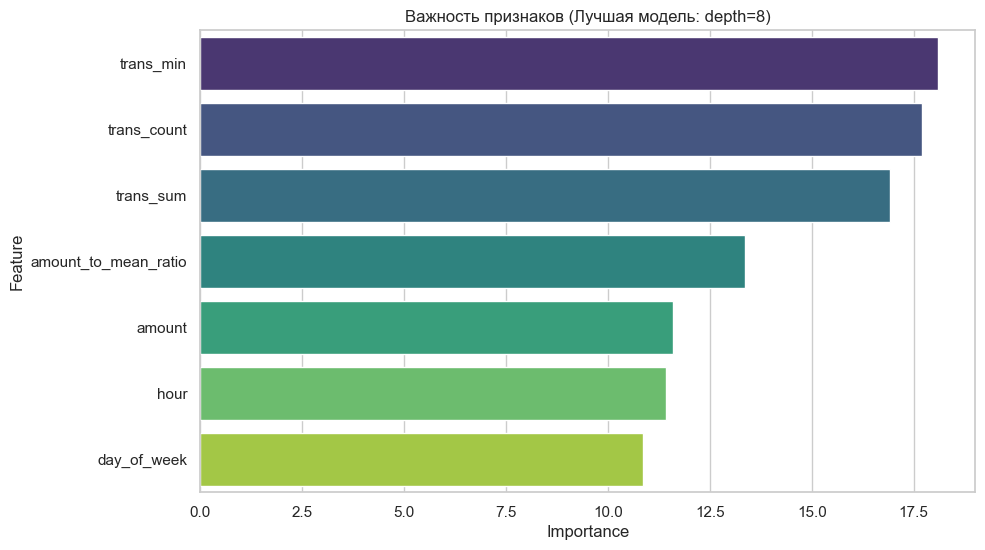

Модель успешно сохранена: ../models/catboost_fraud_model_cv.cbm


In [5]:
# График важности признаков
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df, hue='Feature', legend=False, palette='viridis')
plt.title(f"Важность признаков (Лучшая модель: depth={grid_search.best_params_['depth']})")
plt.show()

# Сохранение идеальной модели
model_path = '../models/catboost_fraud_model_cv.cbm'
best_model.save_model(model_path)
print(f"Модель успешно сохранена: {model_path}")

# Эксперименты

In [6]:
print("ЭТАП 1: ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (One-Hot Encoding + GridSearch)")

# Определяем списки колонок
cat_features = ['hour', 'day_of_week']
num_features = [col for col in X_train.columns if col not in cat_features]

# Создаем препроцессор: для чисел - скейлер, для категорий - OHE
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Собираем всё в единый пайплайн
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# Сетка гиперпараметров: перебираем силу регуляризации C
param_grid_lr = {'classifier__C': [0.01, 0.1, 1.0, 10.0]}
tscv = TimeSeriesSplit(n_splits=3)

# Запускаем поиск
grid_lr = GridSearchCV(
    estimator=pipeline_lr, 
    param_grid=param_grid_lr, 
    cv=tscv, 
    scoring='average_precision', 
    verbose=1,
    n_jobs=-1
)

print("Начинаем подбор гиперпараметров для LogReg...")
grid_lr.fit(X_train, y_train)

# Оценка лучшей модели
best_lr = grid_lr.best_estimator_
y_probs_lr_best = best_lr.predict_proba(X_test)[:, 1]

print(f"\nЛучшие параметры LogReg (OHE): {grid_lr.best_params_}")
print(f"LogReg ROC-AUC на тесте: {roc_auc_score(y_test, y_probs_lr_best):.4f}")
print(f"LogReg PR-AUC на тесте:  {average_precision_score(y_test, y_probs_lr_best):.4f}")

ЭТАП 1: ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (One-Hot Encoding + GridSearch)
Начинаем подбор гиперпараметров для LogReg...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Лучшие параметры LogReg (OHE): {'classifier__C': 1.0}
LogReg ROC-AUC на тесте: 0.5066
LogReg PR-AUC на тесте:  0.0009


In [7]:
print("\nЭТАП 2: LightGBM (Встроенная обработка категорий + GridSearch)")

# Переводим строковые колонки в тип 'category' для LightGBM
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in cat_features:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

lgbm_base = lgb.LGBMClassifier(scale_pos_weight=pos_weight, random_state=42, n_jobs=-1, verbose=-1)

param_grid_lgb = {
    'max_depth': [6, 8],
    'learning_rate': [0.03, 0.1],
    'n_estimators': [200, 500]
}

# n_jobs=1 для самого GridSearch, так как LightGBM сам отлично распараллеливает деревья
grid_lgb = GridSearchCV(
    estimator=lgbm_base, 
    param_grid=param_grid_lgb, 
    cv=tscv, 
    scoring='average_precision', 
    verbose=1,
    n_jobs=1 
)

print("Начинаем подбор гиперпараметров для LightGBM...")
grid_lgb.fit(X_train_lgb, y_train, categorical_feature=cat_features)

best_lgb = grid_lgb.best_estimator_
y_probs_lgb_best = best_lgb.predict_proba(X_test_lgb)[:, 1]

print(f"\nЛучшие параметры LightGBM: {grid_lgb.best_params_}")
print(f"LightGBM ROC-AUC на тесте: {roc_auc_score(y_test, y_probs_lgb_best):.4f}")
print(f"LightGBM PR-AUC на тесте:  {average_precision_score(y_test, y_probs_lgb_best):.4f}")


ЭТАП 2: LightGBM (Встроенная обработка категорий + GridSearch)
Начинаем подбор гиперпараметров для LightGBM...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Лучшие параметры LightGBM: {'learning_rate': 0.03, 'max_depth': 8, 'n_estimators': 200}
LightGBM ROC-AUC на тесте: 0.5000
LightGBM PR-AUC на тесте:  0.0008


In [8]:
print("\nЭТАП 3: GridSearch НА ДАННЫХ С ТАРГЕТ-ЭНКОДИНГОМ")

# 1. Готовим данные с Target Encoding заново (строго по Train)
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

for col in cat_features:
    target_mean = y_train.groupby(X_train[col]).mean()
    X_train_enc[f'{col}_te'] = X_train[col].map(target_mean)
    X_test_enc[f'{col}_te'] = X_test[col].map(target_mean).fillna(y_train.mean())
    X_train_enc = X_train_enc.drop(columns=[col])
    X_test_enc = X_test_enc.drop(columns=[col])

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

# ---------------------------------------------------------
# 2. Тюнинг LogReg на Target Encoding
# ---------------------------------------------------------
print("\nНачинаем подбор для LogReg (Target Encoding)...")
param_grid_lr_te = {'C': [0.01, 0.1, 1.0, 10.0]}

grid_lr_te = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid=param_grid_lr_te, cv=tscv, scoring='average_precision', verbose=1, n_jobs=-1
)
grid_lr_te.fit(X_train_scaled, y_train)

best_lr_te = grid_lr_te.best_estimator_
y_probs_lr_te = best_lr_te.predict_proba(X_test_scaled)[:, 1]

print(f"Лучшие параметры LogReg (TE): {grid_lr_te.best_params_}")
print(f"LogReg (TE) ROC-AUC: {roc_auc_score(y_test, y_probs_lr_te):.4f}")
print(f"LogReg (TE) PR-AUC:  {average_precision_score(y_test, y_probs_lr_te):.4f}")

# ---------------------------------------------------------
# 3. Тюнинг LightGBM на Target Encoding
# ---------------------------------------------------------
print("\nНачинаем подбор для LightGBM (Target Encoding)...")

param_grid_lgb_te = {
    'max_depth': [6, 8],
    'learning_rate': [0.03, 0.1],
    'n_estimators': [200, 500]
}

grid_lgb_te = GridSearchCV(
    estimator=lgb.LGBMClassifier(scale_pos_weight=pos_weight, random_state=42, n_jobs=-1, verbose=-1),
    param_grid=param_grid_lgb_te, cv=tscv, scoring='average_precision', verbose=1, n_jobs=1
)
grid_lgb_te.fit(X_train_enc, y_train)

best_lgb_te = grid_lgb_te.best_estimator_
y_probs_lgb_te = best_lgb_te.predict_proba(X_test_enc)[:, 1]

print(f"Лучшие параметры LightGBM (TE): {grid_lgb_te.best_params_}")
print(f"LightGBM (TE) ROC-AUC: {roc_auc_score(y_test, y_probs_lgb_te):.4f}")
print(f"LightGBM (TE) PR-AUC:  {average_precision_score(y_test, y_probs_lgb_te):.4f}")


ЭТАП 3: GridSearch НА ДАННЫХ С ТАРГЕТ-ЭНКОДИНГОМ

Начинаем подбор для LogReg (Target Encoding)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Лучшие параметры LogReg (TE): {'C': 0.1}
LogReg (TE) ROC-AUC: 0.5055
LogReg (TE) PR-AUC:  0.0009

Начинаем подбор для LightGBM (Target Encoding)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Лучшие параметры LightGBM (TE): {'learning_rate': 0.03, 'max_depth': 8, 'n_estimators': 500}
LightGBM (TE) ROC-AUC: 0.5167
LightGBM (TE) PR-AUC:  0.0009


In [9]:
print("\nЭТАП 4: АНСАМБЛИРОВАНИЕ (Блендинг 3-х лучших моделей)")

# Собираем вероятности от победителей наших GridSearch:
# y_probs          -> CatBoost (из 4-й ячейки)
# y_probs_lgb_best -> LightGBM (из 7-й ячейки)
# y_probs_lr_best  -> LogReg (из 6-й ячейки)

# Дадим бустингам (CatBoost и LightGBM) по 45% веса, а регрессии - 10% для подстраховки.
y_probs_blend = (y_probs * 0.45) + (y_probs_lgb_best * 0.45) + (y_probs_lr_best * 0.10)

# Считаем итоговые метрики ансамбля
blend_roc_auc = roc_auc_score(y_test, y_probs_blend)
blend_ap = average_precision_score(y_test, y_probs_blend)

print(f"Ансамбль ROC-AUC: {blend_roc_auc:.4f}")
print(f"Ансамбль PR-AUC:  {blend_ap:.4f}")

# Решаем бизнес-задачу для ансамбля (Recall >= 70%)
precisions_b, recalls_b, thresholds_b = precision_recall_curve(y_test, y_probs_blend)
valid_indices_b = np.where(recalls_b >= 0.70)[0]

if len(valid_indices_b) > 0:
    best_index_b = valid_indices_b[np.argmax(precisions_b[valid_indices_b])]
    print("\n--- БИЗНЕС-МЕТРИКИ АНСАМБЛЯ ---")
    print(f"Оптимальный порог: {thresholds_b[best_index_b]:.4f}")
    print(f"Precision:         {precisions_b[best_index_b]:.4f}")
    print(f"Recall:            {recalls_b[best_index_b]:.4f}")
else:
    print("\nАнсамбль не смог достичь Recall >= 70%.")


ЭТАП 4: АНСАМБЛИРОВАНИЕ (Блендинг 3-х лучших моделей)
Ансамбль ROC-AUC: 0.6572
Ансамбль PR-AUC:  0.2376

--- БИЗНЕС-МЕТРИКИ АНСАМБЛЯ ---
Оптимальный порог: 0.3509
Precision:         0.0013
Recall:            0.8198


In [13]:
print("ЭТАП 5: ТОНКАЯ НАСТРОЙКА ВЕСОВ (CatBoost)")

# Базовая модель без автоматической балансировки
cb_manual = CatBoostClassifier(
    random_state=42,
    verbose=0,
    task_type='GPU', 
    devices='0'
)

# Жестко фиксируем твои лучшие параметры, перебираем ТОЛЬКО веса
param_grid_weights = {
    'class_weights': [[1, 1], [1, 10], [1, 35], [1, 100]],
    'depth': [8],
    'iterations': [500]
}

grid_weights = GridSearchCV(
    estimator=cb_manual,
    param_grid=param_grid_weights,
    cv=tscv, 
    scoring='average_precision',
    verbose=2
)

print("Начинаем подбор ручных весов на оптимальной глубине...")
grid_weights.fit(X_train, y_train, cat_features=cat_features)

best_cb_weights = grid_weights.best_estimator_
y_probs_weights = best_cb_weights.predict_proba(X_test)[:, 1]

print(f"\nЛучшие веса: {grid_weights.best_params_['class_weights']}")
print(f"CatBoost (Ручные веса) ROC-AUC: {roc_auc_score(y_test, y_probs_weights):.4f}")
print(f"CatBoost (Ручные веса) PR-AUC:  {average_precision_score(y_test, y_probs_weights):.4f}")

# Оценка бизнес-метрик
precisions_w, recalls_w, thresholds_w = precision_recall_curve(y_test, y_probs_weights)
valid_w = np.where(recalls_w >= 0.70)[0]

if len(valid_w) > 0:
    best_idx_w = valid_w[np.argmax(precisions_w[valid_w])]
    print("\n--- БИЗНЕС-МЕТРИКИ (Ручные веса) ---")
    print(f"Оптимальный порог: {thresholds_w[best_idx_w]:.4f}")
    print(f"Precision:         {precisions_w[best_idx_w]:.4f}")
    print(f"Recall:            {recalls_w[best_idx_w]:.4f}")

=== ЭТАП 5: ТОНКАЯ НАСТРОЙКА ВЕСОВ (CatBoost) ===
Начинаем подбор ручных весов на оптимальной глубине...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ......class_weights=[1, 1], depth=8, iterations=500; total time=  25.5s
[CV] END ......class_weights=[1, 1], depth=8, iterations=500; total time=  45.3s
[CV] END ......class_weights=[1, 1], depth=8, iterations=500; total time= 1.2min
[CV] END .....class_weights=[1, 10], depth=8, iterations=500; total time=  29.7s
[CV] END .....class_weights=[1, 10], depth=8, iterations=500; total time=  45.5s
[CV] END .....class_weights=[1, 10], depth=8, iterations=500; total time= 1.1min
[CV] END .....class_weights=[1, 35], depth=8, iterations=500; total time=  24.0s
[CV] END .....class_weights=[1, 35], depth=8, iterations=500; total time=  40.9s
[CV] END .....class_weights=[1, 35], depth=8, iterations=500; total time= 1.1min
[CV] END ....class_weights=[1, 100], depth=8, iterations=500; total time=  23.5s
[CV] END ....class_weight

In [14]:
print("\nЭТАП 6: ДВУХСТАДИЙНАЯ ФИЛЬТРАЦИЯ (Каскад моделей)")

# --- СТАДИЯ 1: Базовая фильтрация ---
model_stage_1 = best_cb_weights 

# Получаем предсказания для ТРЕЙНА
y_train_probs_s1 = model_stage_1.predict_proba(X_train)[:, 1]

# Определяем пороги серой зоны (где модель сомневается)
gray_zone_mask = (y_train_probs_s1 > 0.05) & (y_train_probs_s1 < 0.80)

X_train_gray = X_train[gray_zone_mask]
y_train_gray = y_train[gray_zone_mask]

print(f"Размер исходного трейна: {len(X_train)} строк")
print(f"Размер серой зоны для Стадии 2: {len(X_train_gray)} строк")

# --- СТАДИЯ 2: Микро-модель для серой зоны ---
if len(X_train_gray) > 1000:
    # Обучаем вторую модель с твоими оптимальными параметрами
    model_stage_2 = CatBoostClassifier(
        depth=8,               # Твой лучший параметр
        iterations=500,        # Твой лучший параметр
        auto_class_weights='Balanced', 
        random_state=42, 
        verbose=0,
        task_type='GPU',
        devices='0'
    )
    model_stage_2.fit(X_train_gray, y_train_gray, cat_features=cat_features)
    
    # --- ТЕСТИРОВАНИЕ КАСКАДА ---
    y_test_probs_s1 = model_stage_1.predict_proba(X_test)[:, 1]
    y_test_probs_final = y_test_probs_s1.copy()
    
    test_gray_mask = (y_test_probs_s1 > 0.05) & (y_test_probs_s1 < 0.80)
    X_test_gray = X_test[test_gray_mask]
    
    if len(X_test_gray) > 0:
        y_test_probs_final[test_gray_mask] = model_stage_2.predict_proba(X_test_gray)[:, 1]

    print("\n--- ИТОГОВЫЕ МЕТРИКИ КАСКАДА ---")
    print(f"Каскад ROC-AUC: {roc_auc_score(y_test, y_test_probs_final):.4f}")
    print(f"Каскад PR-AUC:  {average_precision_score(y_test, y_test_probs_final):.4f}")
    
    precisions_c, recalls_c, thresholds_c = precision_recall_curve(y_test, y_test_probs_final)
    valid_c = np.where(recalls_c >= 0.70)[0]

    if len(valid_c) > 0:
        best_idx_c = valid_c[np.argmax(precisions_c[valid_c])]
        print("\n--- БИЗНЕС-МЕТРИКИ КАСКАДА ---")
        print(f"Оптимальный порог: {thresholds_c[best_idx_c]:.4f}")
        print(f"Precision:         {precisions_c[best_idx_c]:.4f}")
        print(f"Recall:            {recalls_c[best_idx_c]:.4f}")
else:
    print("В серой зоне слишком мало данных для обучения второй стадии.")


ЭТАП 6: ДВУХСТАДИЙНАЯ ФИЛЬТРАЦИЯ (Каскад моделей)
Размер исходного трейна: 2755091 строк
Размер серой зоны для Стадии 2: 1388053 строк

--- ИТОГОВЫЕ МЕТРИКИ КАСКАДА ---
Каскад ROC-AUC: 0.8216
Каскад PR-AUC:  0.2127

--- БИЗНЕС-МЕТРИКИ КАСКАДА ---
Оптимальный порог: 0.3002
Precision:         0.0040
Recall:            0.7002


In [17]:
print("ЭТАП 7: СОХРАНЕНИЕ КАСКАДА")

# 1. Перезаписываем старый файл новой, более точной моделью (с весами [1, 100])
model_stage_1.save_model('../models/catboost_fraud_model_cv.cbm')

# 2. Досохраняем модель для серой зоны
model_stage_2.save_model('../models/catboost_stage_2_gray_zone.cbm')

print("Каскад полностью сохранен")

ЭТАП 7: СОХРАНЕНИЕ КАСКАДА
Каскад полностью сохранен
